## Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane import numpy as pnp

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

np.random.seed(1234)

## Load, reduce, and split the data


In [7]:
data = load_breast_cancer()
X = data.data
y = data.target

X_scaled = StandardScaler().fit_transform(X)
X = PCA(n_components=2).fit_transform(X_scaled)
y = y * 2 - 1 
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

## Scale features for angle encoding

In [8]:
scaler = MinMaxScaler((-np.pi, np.pi)).fit(Xtr)
Xtr = scaler.transform(Xtr)
Xte = np.clip(scaler.transform(Xte), -np.pi, np.pi)

Xtr = pnp.array(Xtr)
ytr = pnp.array(ytr, dtype=float)

## Create the data-reuploading VQC

In [9]:
n_qubits = 2
n_layers = 3
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, diff_method="backprop")
def circuit(weights, x):
    for L in range(n_layers):
        qml.AngleEmbedding(x, wires=range(n_qubits))     
        for i in range(n_qubits):
            qml.Rot(weights[L, i, 0], weights[L, i, 1], weights[L, i, 2], wires=i)
        qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0))

def model(weights, bias, x):
    return circuit(weights, x) + bias

## Train the data re-uploading VQC


In [10]:
def cost(weights, bias, X, Y):
    preds = pnp.stack([model(weights, bias, x) for x in X])
    return pnp.mean((Y - preds) ** 2)

weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)
opt = qml.NesterovMomentumOptimizer(0.2)

loss_history = []
for step in range(40):
    weights, bias, _, _ = opt.step(cost, weights, bias, Xtr, ytr)
    loss_history.append(float(cost(weights, bias, Xtr, ytr)))

print("final training loss:", round(loss_history[-1], 4))

final training loss: 0.2169


## Generate model output over an input grid

Evaluate the trained model across the 2D feature space so the decision surface can be seen.

In [11]:
n_grid = 100

g = np.linspace(-np.pi, np.pi, n_grid)
GX, GY = np.meshgrid(g, g)
grid = np.column_stack([GX.ravel(), GY.ravel()])

Z_reup = np.array([float(model(weights, bias, pnp.array(p))) for p in grid])
Z_reup = Z_reup.reshape(GX.shape)

print("grid shape:", Z_reup.shape, " output range:", round(Z_reup.min(), 3), "to", round(Z_reup.max(), 3))

grid shape: (100, 100)  output range: -0.958 to 0.979


## Create basic VQC for comparison

Rebuild the basic circuit from Week 2 and run it through the same grid in order to compare its decision surface to the re-uploading model's.

In [12]:
@qml.qnode(dev, diff_method="backprop")
def circuit_basic(weights, x):
    qml.AngleEmbedding(x, wires=range(n_qubits))
    for i in range(n_qubits):
        qml.Rot(weights[i, 0], weights[i, 1], weights[i, 2], wires=i)
    qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0))

def model_basic(weights, bias, x):
    return circuit_basic(weights, x) + bias

## Train the basic VQC

Trained the basic VQC using the same cost function and optimizer to ensure accurate comparsison

In [13]:
def cost_basic(weights, bias, X, Y):
    preds = pnp.stack([model_basic(weights, bias, x) for x in X])
    return pnp.mean((Y - preds) ** 2)

weights_basic = pnp.array(0.01 * np.random.randn(n_qubits, 3), requires_grad=True)
bias_basic = pnp.array(0.0, requires_grad=True)
opt_basic = qml.NesterovMomentumOptimizer(0.2)

for step in range(40):
    weights_basic, bias_basic, _, _ = opt_basic.step(cost_basic, weights_basic, bias_basic, Xtr, ytr)

print("basic final loss:", round(float(cost_basic(weights_basic, bias_basic, Xtr, ytr)), 4))

basic final loss: 0.2869


## Generate model output over an ithe input grid

Evaluate the basic VQC across the 2D feature space so its decision surface can be seen.

In [14]:
Z_basic = np.array([float(model_basic(weights_basic, bias_basic, pnp.array(p))) for p in grid])
Z_basic = Z_basic.reshape(GX.shape)

print("Z_basic shape:", Z_basic.shape, " output range:", round(Z_basic.min(), 3), "to", round(Z_basic.max(), 3))

Z_basic shape: (100, 100)  output range: -0.997 to 0.927


## Fourier transform on the decision surfaces

Applies a 2D fourier transform to both of the decision surfaces to take the  spectrum magnitudes, showing which waves each model used.

In [15]:
def magnitude_spectrum(Z):
    F = np.fft.fft2(Z)            
    F = np.fft.fftshift(F)        
    return np.abs(F) / Z.size     

S_basic = magnitude_spectrum(Z_basic)
S_reup = magnitude_spectrum(Z_reup)

# frequency index for each row/column (0 at center, +/- outward)
freqs = np.fft.fftshift(np.fft.fftfreq(n_grid, d=1.0 / n_grid))

print("spectrum shape:", S_basic.shape)
print("basic  peak magnitude:", round(S_basic.max(), 4))
print("reup   peak magnitude:", round(S_reup.max(), 4))

spectrum shape: (100, 100)
basic  peak magnitude: 0.4829
reup   peak magnitude: 0.4636


## Plots magnitude spectra

Displays both the spesctra side by side, zoomed in to show the frequencies

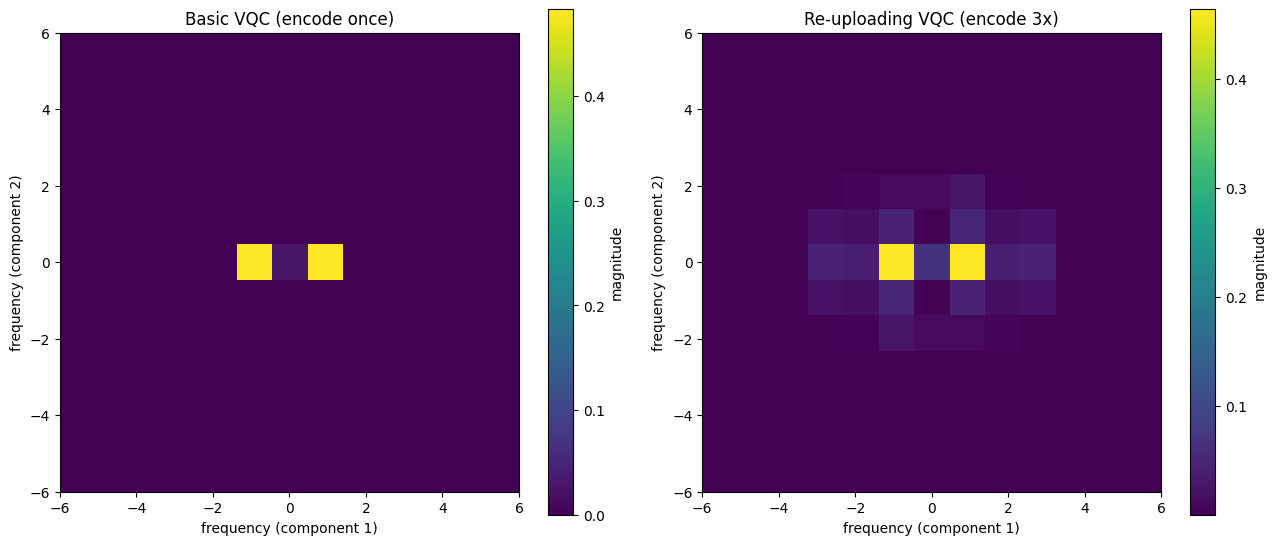

In [16]:
zoom = 6
center = n_grid // 2
lo, hi = center - zoom, center + zoom + 1

sub_freqs = freqs[lo:hi]
extent = [sub_freqs.min(), sub_freqs.max(), sub_freqs.min(), sub_freqs.max()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, S, title in zip(axes, [S_basic, S_reup],
                        ["Basic VQC (encode once)", "Re-uploading VQC (encode 3x)"]):
    sub = S[lo:hi, lo:hi]
    im = ax.imshow(sub, extent=extent, origin="lower", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("frequency (component 1)")
    ax.set_ylabel("frequency (component 2)")
    ax.set_xticks(range(-zoom, zoom + 1, 2))
    ax.set_yticks(range(-zoom, zoom + 1, 2))
    plt.colorbar(im, ax=ax, label="magnitude")

plt.tight_layout()
plt.show()

## Create table of strongest frequencies

Gathers the strongest frequencies used by both of the models and puts them into a table for comparison

In [17]:
def top_frequencies(S, name, n=5):
    flat = np.argsort(S.ravel())[::-1][:n]
    rows = []
    for idx in flat:
        i, j = np.unravel_index(idx, S.shape)
        rows.append({
            "model": name,
            "freq (comp 1)": int(freqs[j]),
            "freq (comp 2)": int(freqs[i]),
            "magnitude": round(float(S[i, j]), 4),
        })
    return pd.DataFrame(rows)

table = pd.concat([
    top_frequencies(S_basic, "basic (encode 1x)"),
    top_frequencies(S_reup, "re-uploading (encode 3x)"),
], ignore_index=True)

table

,model,freq (comp 1),freq (comp 2),magnitude
0,basic (encode 1x),-1,0,0.4829
1,basic (encode 1x),1,0,0.4829
2,basic (encode 1x),0,0,0.0258
3,basic (encode 1x),-2,0,0.0037
4,basic (encode 1x),2,0,0.0037
5,re-uploading (encode 3x),-1,0,0.4636
6,re-uploading (encode 3x),1,0,0.4636
7,re-uploading (encode 3x),0,0,0.0679
8,re-uploading (encode 3x),-1,-1,0.0471
9,re-uploading (encode 3x),1,1,0.0471
